In [6]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [7]:
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


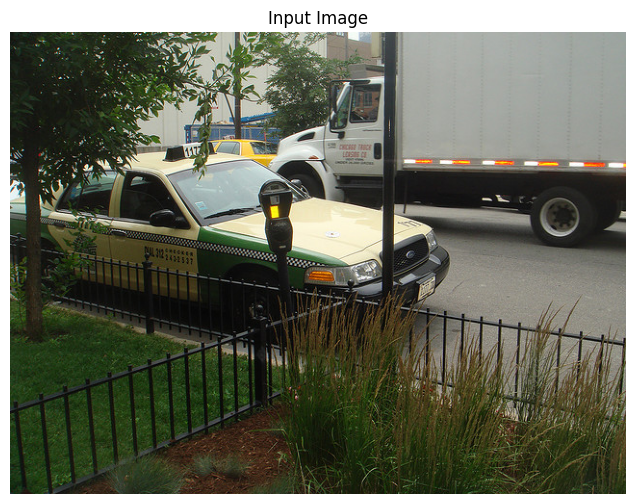

In [25]:
img = cv2.imread("test.png")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Input Image")
plt.axis('off')
plt.show()

In [26]:
model = hub.load("https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2")

In [28]:
image = tf.convert_to_tensor(img_rgb)
image = image[tf.newaxis,...]

In [29]:
result = model(image)

boxes = result["detection_boxes"][0].numpy()
scores = result["detection_scores"][0].numpy()
classes = result["detection_classes"][0].numpy()

In [30]:
h, w, _ = img.shape

for i in range(5):
    if scores[i] > 0.5:
        y1, x1, y2, x2 = boxes[i]
        cv2.rectangle(img, (int(x1*w), int(y1*h)), (int(x2*w), int(y2*h)), (0,255,0), 2)

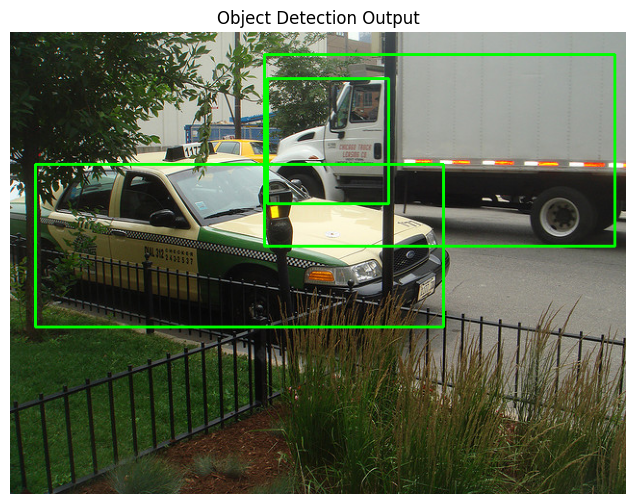

In [31]:
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,6))
plt.imshow(img_rgb)
plt.title("Object Detection Output")
plt.axis('off')
plt.show()

In [32]:
print("Confidence Scores")
print(scores[:5])

Confidence Scores
[0.82548374 0.75122046 0.51604486 0.44536555 0.39049158]
